# Clase 6 — Instancia de Evaluación: SVM vs. SGDClassifier

**Alumno:** Gallego, Ian  
**Materia:** Aprendizaje Automático  
**Institución:** Politécnico Malvinas Argentinas  
**Fecha:** Mayo 2026

---

## Consigna

> Elegir **2 modelos de clasificación** vistos en el bloque y, utilizando un dataset de interés, aplicar ambos modelos para resolver un problema de aprendizaje automático. Evaluar cada modelo y concluir cuál aborda mejor el problema.

---

## Decisiones tomadas

| | Elección | Justificación |
|--|---------|---------------|
| **Modelos** | SVM (kernel RBF) y SGDClassifier | Ambos vistos en Clase 6; representan enfoques distintos: margen máximo vs. optimización estocástica |
| **Dataset** | Breast Cancer Wisconsin (`sklearn.datasets`) | Problema clínico real, clasificación binaria (maligno/benigno), 569 muestras, 30 features numéricas, sin valores nulos, fácil de interpretar en el video |
| **Problema** | Predecir si un tumor es maligno o benigno a partir de características celulares medidas por imágenes |

---

## Estructura del notebook

| Sección | Contenido |
|---------|----------|
| 1 | Dataset — carga, EDA y visualización |
| 2 | Preprocesamiento — split y escalado |
| 3 | Modelo 1 — SVM con kernel RBF |
| 4 | Modelo 2 — SGDClassifier |
| 5 | Comparación de modelos |
| 6 | Conclusión y guión del video |

In [1]:
# Verificar e instalar dependencias si es necesario
import subprocess, sys
required = ["scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"]
for pkg in required:
    try:
        __import__(pkg.replace("-", "_").split(".")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Librerías cargadas correctamente.")
import sklearn
print(f"scikit-learn {sklearn.__version__} | numpy {np.__version__} | pandas {pd.__version__}")

Librerías cargadas correctamente.
scikit-learn 1.7.2 | numpy 2.2.6 | pandas 2.3.3


---
## Sección 1: Dataset — Breast Cancer Wisconsin

### 1.1 Carga y estructura

El dataset **Breast Cancer Wisconsin** contiene mediciones de núcleos celulares obtenidas por digitalización de imágenes de biopsia de tejido mamario. El objetivo es clasificar cada muestra como:
- **0 — Maligno:** tumor cancerígeno
- **1 — Benigno:** tumor no cancerígeno

Cada feature representa una característica geométrica de las células (radio, textura, perímetro, área, suavidad, etc.), calculada como media, error estándar y peor valor.

In [2]:
# Cargar dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["target"] = cancer.target
df["diagnostico"] = df["target"].map({0: "Maligno", 1: "Benigno"})

print(f"Shape del dataset: {df.shape}  ({df.shape[0]} muestras × {df.shape[1]-2} features + target)")
print(f"\nClases: {cancer.target_names.tolist()}")
print(f"  Maligno (0): {(df.target == 0).sum()} muestras  ({(df.target == 0).mean()*100:.1f}%)")
print(f"  Benigno (1): {(df.target == 1).sum()} muestras  ({(df.target == 1).mean()*100:.1f}%)")
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print("\n=== Primeras 5 filas ===")
display(df[["diagnostico"] + list(cancer.feature_names[:6])].head())
print("\n=== Estadísticas descriptivas (primeras 6 features) ===")
display(df[list(cancer.feature_names[:6])].describe().round(3))

Shape del dataset: (569, 32)  (569 muestras × 30 features + target)

Clases: ['malignant', 'benign']
  Maligno (0): 212 muestras  (37.3%)
  Benigno (1): 357 muestras  (62.7%)

Valores nulos: 0

=== Primeras 5 filas ===


,diagnostico,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,Maligno,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,Maligno,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,Maligno,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,Maligno,11.42,20.38,77.58,386.1,0.14250,0.28390
4,Maligno,20.29,14.34,135.10,1297.0,0.10030,0.13280



=== Estadísticas descriptivas (primeras 6 features) ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
count,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104
std,3.524,4.301,24.299,351.914,0.014,0.053
min,6.981,9.710,43.790,143.500,0.053,0.019
25%,11.700,16.170,75.170,420.300,0.086,0.065
50%,13.370,18.840,86.240,551.100,0.096,0.093
75%,15.780,21.800,104.100,782.700,0.105,0.130
max,28.110,39.280,188.500,2501.000,0.163,0.345


### 1.2 Análisis Exploratorio (EDA)

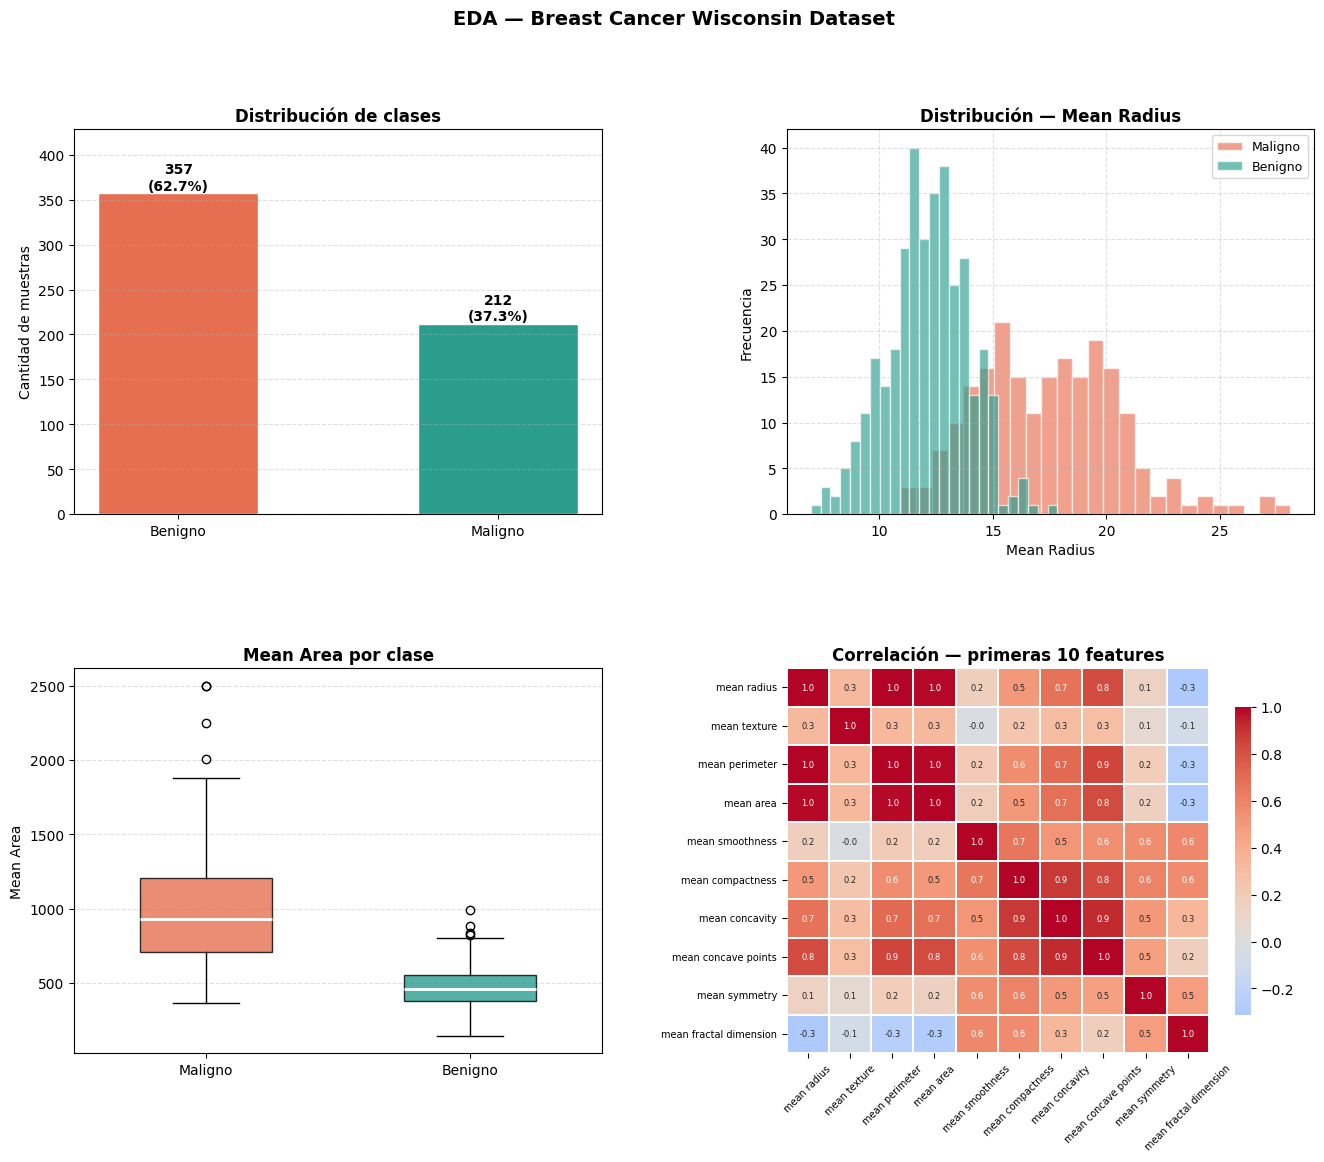

→ Figura EDA guardada como clase6_eda.png


In [3]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("EDA — Breast Cancer Wisconsin Dataset", fontsize=14, fontweight='bold')

COL_MAL = "#e76f51"
COL_BEN = "#2a9d8f"

# 1. Distribución de clases
ax1 = fig.add_subplot(gs[0, 0])
conteo = df["diagnostico"].value_counts()
bars = ax1.bar(conteo.index, conteo.values,
               color=[COL_MAL, COL_BEN], edgecolor="white", width=0.5)
for bar, val in zip(bars, conteo.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f"{val}\n({val/len(df)*100:.1f}%)",
             ha='center', fontsize=10, fontweight='bold')
ax1.set_title("Distribución de clases", fontweight='bold')
ax1.set_ylabel("Cantidad de muestras")
ax1.set_ylim(0, conteo.max() * 1.2)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# 2. Distribución de las 3 features más importantes (mean radius, mean texture, mean area)
ax2 = fig.add_subplot(gs[0, 1])
for label, color, name in [(0, COL_MAL, "Maligno"), (1, COL_BEN, "Benigno")]:
    subset = df[df["target"] == label]["mean radius"]
    ax2.hist(subset, bins=25, alpha=0.65, color=color, label=name, edgecolor='white')
ax2.set_title("Distribución — Mean Radius", fontweight='bold')
ax2.set_xlabel("Mean Radius")
ax2.set_ylabel("Frecuencia")
ax2.legend(fontsize=9)
ax2.grid(linestyle='--', alpha=0.4)

# 3. Boxplot: mean area por clase
ax3 = fig.add_subplot(gs[1, 0])
data_mal = df[df["target"] == 0]["mean area"]
data_ben = df[df["target"] == 1]["mean area"]
bp = ax3.boxplot([data_mal, data_ben], patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(COL_MAL); bp['boxes'][0].set_alpha(0.8)
bp['boxes'][1].set_facecolor(COL_BEN); bp['boxes'][1].set_alpha(0.8)
ax3.set_xticklabels(["Maligno", "Benigno"])
ax3.set_title("Mean Area por clase", fontweight='bold')
ax3.set_ylabel("Mean Area")
ax3.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Heatmap de correlación (primeras 10 features)
ax4 = fig.add_subplot(gs[1, 1])
features_10 = list(cancer.feature_names[:10])
corr = df[features_10].corr()
sns.heatmap(corr, ax=ax4, cmap="coolwarm", center=0,
            annot=True, fmt=".1f", annot_kws={"size": 6},
            linewidths=0.3, cbar_kws={"shrink": 0.8})
ax4.set_title("Correlación — primeras 10 features", fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=7)
ax4.tick_params(axis='y', rotation=0,  labelsize=7)

plt.savefig("clase6_eda.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura EDA guardada como clase6_eda.png")

---
## Sección 2: Preprocesamiento

### ¿Por qué escalar los datos?

Tanto **SVM** como **SGDClassifier** son algoritmos sensibles a la escala de las features:

- **SVM** calcula distancias entre puntos y el hiperplano. Si `mean area` (rango 143–2501) y `mean smoothness` (rango 0.05–0.16) no se escalan, el área dominará completamente el cálculo del margen, ignorando features pequeñas que pueden ser igualmente informativas.
- **SGDClassifier** actualiza los pesos mediante gradiente. Con features en distintas escalas, el gradiente será enorme para unas variables y mínimo para otras, causando oscilaciones en la convergencia.

Se aplica **StandardScaler** (Z-score): resta la media y divide por la desviación estándar → todas las features quedan con media ≈ 0 y std ≈ 1. El scaler se ajusta **solo sobre el conjunto de entrenamiento** para evitar data leakage.

In [4]:
X = df[list(cancer.feature_names)].values
y = df["target"].values

# Split 80/20 estratificado (mantiene proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Escalado — fit SOLO en train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)          # transform (no fit) en test

print("=== Split del dataset ===")
print(f"  Total:      {len(X)} muestras")
print(f"  Entrenamiento: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test:          {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Maligno en train: {(y_train==0).sum()} | en test: {(y_test==0).sum()}")
print(f"  Benigno en train: {(y_train==1).sum()} | en test: {(y_test==1).sum()}")
print(f"\nEscalado aplicado:")
print(f"  mean radius — antes: [{X_train[:,0].min():.2f}, {X_train[:,0].max():.2f}]")
print(f"  mean radius — después: [{X_train_sc[:,0].min():.2f}, {X_train_sc[:,0].max():.2f}]")
print(f"  Media tras escalado: {X_train_sc.mean():.6f}  (≈ 0)")
print(f"  Std  tras escalado: {X_train_sc.std():.6f}   (≈ 1)")

=== Split del dataset ===
  Total:      569 muestras
  Entrenamiento: 455 (80%)
  Test:          114  (20%)

  Maligno en train: 170 | en test: 42
  Benigno en train: 285 | en test: 72

Escalado aplicado:
  mean radius — antes: [6.98, 28.11]
  mean radius — después: [-2.03, 4.02]
  Media tras escalado: -0.000000  (≈ 0)
  Std  tras escalado: 1.000000   (≈ 1)


---
## Sección 3: Modelo 1 — Support Vector Machine (SVM)

### ¿Cómo funciona SVM?

SVM busca el **hiperplano de margen máximo**: la frontera de decisión que maximiza la distancia entre las clases. Los puntos más cercanos al hiperplano se llaman **vectores de soporte** y son los únicos que definen la frontera (el resto de los datos no influyen).

**Kernel RBF (Radial Basis Function):**  
Cuando los datos no son linealmente separables, SVM usa el **kernel trick**: proyecta los datos a un espacio de mayor dimensión donde sí existe un hiperplano separador. El kernel RBF mide la similitud entre dos puntos usando la distancia euclídea:

$$K(x_i, x_j) = e^{-\gamma \|x_i - x_j\|^2}$$

**Hiperparámetros usados:**
- `C=1.0`: parámetro de regularización. Controla el trade-off entre margen máximo y errores de clasificación. C alto → menos errores tolerados → margen más pequeño.
- `gamma='scale'`: $\gamma = 1/(n\_features \times X.var())$. Controla el radio de influencia de cada muestra de entrenamiento.
- `kernel='rbf'`: kernel de función de base radial, de propósito general.

In [5]:
# Entrenar SVM
t0 = time.time()
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)
t_svm = time.time() - t0

# Predicciones
y_pred_svm = svm.predict(X_test_sc)
acc_svm    = accuracy_score(y_test, y_pred_svm)

# Validación cruzada (5-fold) para una estimación más robusta
cv_svm = cross_val_score(svm, X_train_sc, y_train, cv=5, scoring='accuracy')

print("=" * 55)
print("   MODELO 1 — SVM (kernel RBF)")
print("=" * 55)
print(f"  Tiempo de entrenamiento: {t_svm*1000:.1f} ms")
print(f"  Vectores de soporte:     {svm.n_support_.sum()} "
      f"(Maligno: {svm.n_support_[0]} | Benigno: {svm.n_support_[1]})")
print(f"\n  Accuracy en test:        {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print(f"  CV Accuracy (5-fold):    {cv_svm.mean():.4f} ± {cv_svm.std():.4f}")
print()
print("  Reporte de clasificación:")
print(classification_report(y_test, y_pred_svm,
                             target_names=["Maligno", "Benigno"],
                             digits=4))

   MODELO 1 — SVM (kernel RBF)
  Tiempo de entrenamiento: 5.1 ms
  Vectores de soporte:     97 (Maligno: 51 | Benigno: 46)

  Accuracy en test:        0.9825  (98.25%)
  CV Accuracy (5-fold):    0.9714 ± 0.0179

  Reporte de clasificación:
              precision    recall  f1-score   support

     Maligno     0.9762    0.9762    0.9762        42
     Benigno     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



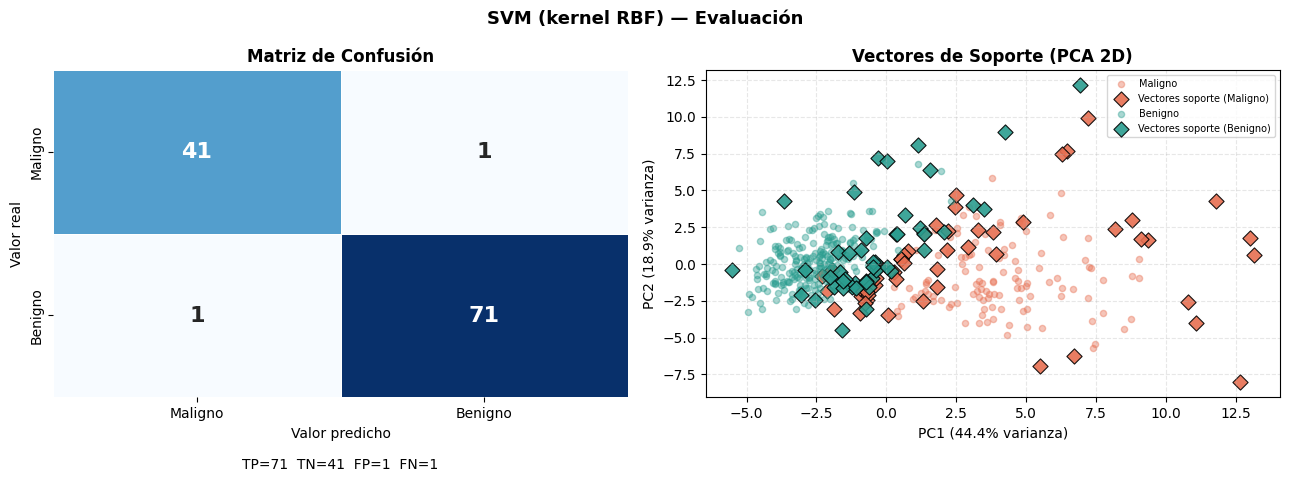

→ Figura SVM guardada como clase6_svm.png
→ Los diamantes negros son los vectores de soporte: 97 de 455 puntos de entrenamiento


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("SVM (kernel RBF) — Evaluación", fontsize=13, fontweight='bold')

# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, ax=axes[0], annot=True, fmt='d', cmap='Blues',
            xticklabels=["Maligno", "Benigno"],
            yticklabels=["Maligno", "Benigno"],
            linewidths=0.5, cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title("Matriz de Confusión", fontweight='bold')
axes[0].set_ylabel("Valor real")
axes[0].set_xlabel("Valor predicho")

tn, fp, fn, tp = cm_svm.ravel()
axes[0].text(0.5, -0.22,
             f"TP={tp}  TN={tn}  FP={fp}  FN={fn}",
             ha='center', transform=axes[0].transAxes, fontsize=10)

# Distribución de vectores de soporte en el espacio de las 2 primeras PCs
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_sc)

# Reconstruir índices de soporte vectors
sv_indices = svm.support_
non_sv = np.setdiff1d(np.arange(len(X_train_sc)), sv_indices)

ax2 = axes[1]
for label, color, name in [(0, "#e76f51", "Maligno"), (1, "#2a9d8f", "Benigno")]:
    idx = np.where(y_train == label)[0]
    idx_non_sv = np.intersect1d(idx, non_sv)
    idx_sv     = np.intersect1d(idx, sv_indices)
    ax2.scatter(X_train_2d[idx_non_sv, 0], X_train_2d[idx_non_sv, 1],
                c=color, alpha=0.4, s=20, label=name)
    ax2.scatter(X_train_2d[idx_sv, 0], X_train_2d[idx_sv, 1],
                c=color, edgecolors='black', linewidths=0.8,
                s=60, marker='D', alpha=0.9,
                label=f"Vectores soporte ({name})")

ax2.set_title("Vectores de Soporte (PCA 2D)", fontweight='bold')
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax2.legend(fontsize=7, loc='upper right')
ax2.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("clase6_svm.png", dpi=110, bbox_inches='tight')
plt.show()
print(f"→ Figura SVM guardada como clase6_svm.png")
print(f"→ Los diamantes negros son los vectores de soporte: {svm.n_support_.sum()} de {len(X_train)} puntos de entrenamiento")

---
## Sección 4: Modelo 2 — SGDClassifier (Gradiente Estocástico Descendente)

### ¿Cómo funciona SGDClassifier?

El **Gradiente Estocástico Descendente** es un método de optimización que ajusta los parámetros del modelo minimizando una función de costo. A diferencia del gradiente descendente batch (que usa todo el dataset por iteración), SGD actualiza los pesos con **una sola muestra aleatoria** por vez:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t, x_i, y_i)$$

donde $\eta$ es la tasa de aprendizaje y $L$ la función de pérdida.

**Configuración usada:**
- `loss='hinge'`: equivale a entrenar un **SVM lineal** mediante SGD. Es la función de pérdida estándar para clasificación con margen.
- `max_iter=1000`: número máximo de épocas (pasadas por el dataset completo).
- `random_state=42`: reproducibilidad.

**Diferencia clave con SVM:**  
SVM resuelve un problema de optimización convexa de forma exacta (quadratic programming). SGD llega a una solución **aproximada** de forma iterativa, lo que lo hace mucho más rápido en datasets grandes pero con menor garantía de encontrar el óptimo global.

In [ ]:
# Entrenar SGDClassifier
t0 = time.time()
sgd = SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3,
                    random_state=42, n_jobs=-1)
sgd.fit(X_train_sc, y_train)
t_sgd = time.time() - t0

# Predicciones
y_pred_sgd = sgd.predict(X_test_sc)
acc_sgd    = accuracy_score(y_test, y_pred_sgd)

# Validación cruzada
cv_sgd = cross_val_score(sgd, X_train_sc, y_train, cv=5, scoring='accuracy')

print("   MODELO 2 — SGDClassifier (loss=hinge)")
print(f"  Tiempo de entrenamiento: {t_sgd*1000:.1f} ms")
print(f"  Iteraciones realizadas:  {sgd.n_iter_}")
print(f"\n  Accuracy en test:        {acc_sgd:.4f}  ({acc_sgd*100:.2f}%)")
print(f"  CV Accuracy (5-fold):    {cv_sgd.mean():.4f} ± {cv_sgd.std():.4f}")
print()
print("  Reporte de clasificación:")
print(classification_report(y_test, y_pred_sgd,
                             target_names=["Maligno", "Benigno"],
                             digits=4))

   MODELO 2 — SGDClassifier (loss=hinge)
  Tiempo de entrenamiento: 2.1 ms
  Iteraciones realizadas:  24

  Accuracy en test:        0.9649  (96.49%)
  CV Accuracy (5-fold):    0.9626 ± 0.0164

  Reporte de clasificación:
              precision    recall  f1-score   support

     Maligno     0.9318    0.9762    0.9535        42
     Benigno     0.9857    0.9583    0.9718        72

    accuracy                         0.9649       114
   macro avg     0.9588    0.9673    0.9627       114
weighted avg     0.9659    0.9649    0.9651       114



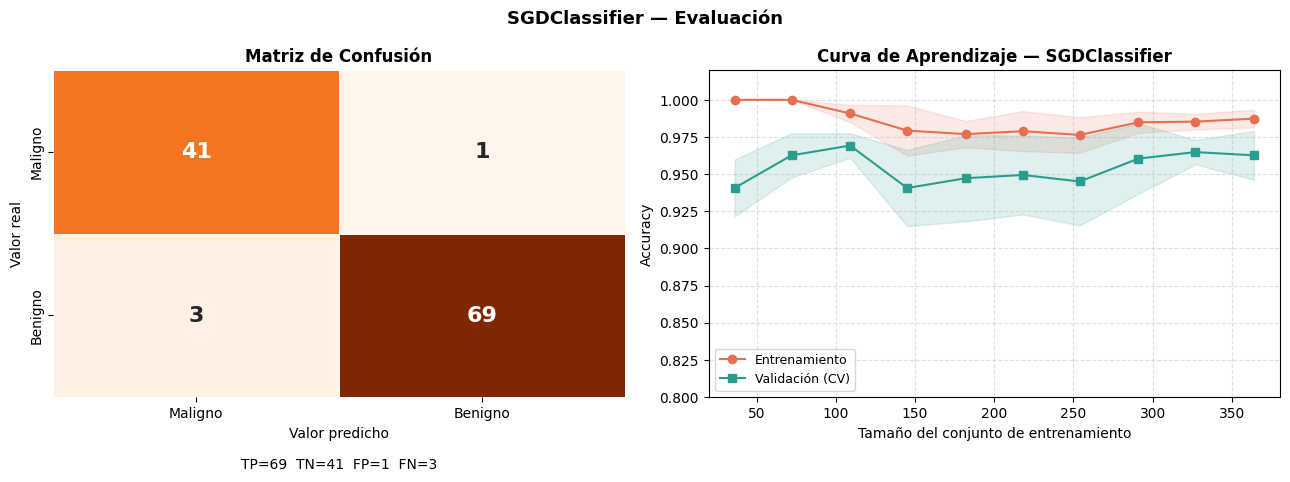

→ Figura SGD guardada como clase6_sgd.png
→ Si las curvas de train y validación convergen: el modelo generaliza bien (sin overfitting).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("SGDClassifier — Evaluación", fontsize=13, fontweight='bold')

# Matriz de confusión
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, ax=axes[0], annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Maligno", "Benigno"],
            yticklabels=["Maligno", "Benigno"],
            linewidths=0.5, cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title("Matriz de Confusión", fontweight='bold')
axes[0].set_ylabel("Valor real")
axes[0].set_xlabel("Valor predicho")

tn2, fp2, fn2, tp2 = cm_sgd.ravel()
axes[0].text(0.5, -0.22,
             f"TP={tp2}  TN={tn2}  FP={fp2}  FN={fn2}",
             ha='center', transform=axes[0].transAxes, fontsize=10)

# Curva de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    SGDClassifier(loss='hinge', max_iter=1000, random_state=42),
    X_train_sc, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax2 = axes[1]
ax2.plot(train_sizes, train_mean, 'o-', color='#e76f51', label='Entrenamiento')
ax2.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='#e76f51')
ax2.plot(train_sizes, val_mean, 's-', color='#2a9d8f', label='Validación (CV)')
ax2.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='#2a9d8f')
ax2.set_title("Curva de Aprendizaje — SGDClassifier", fontweight='bold')
ax2.set_xlabel("Tamaño del conjunto de entrenamiento")
ax2.set_ylabel("Accuracy")
ax2.legend(fontsize=9)
ax2.set_ylim(0.80, 1.02)
ax2.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("clase6_sgd.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura SGD guardada como clase6_sgd.png")
print("→ Si las curvas de train y validación convergen: el modelo generaliza bien (sin overfitting).")

---
## Sección 5: Comparación de Modelos

### 5.1 Tabla comparativa de métricas

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

def metricas(y_true, y_pred, t_train, cv_scores):
    return {
        "Accuracy (test)":      round(accuracy_score(y_true, y_pred), 4),
        "Precision (weighted)": round(precision_score(y_true, y_pred, average='weighted'), 4),
        "Recall (weighted)":    round(recall_score(y_true, y_pred, average='weighted'), 4),
        "F1-score (weighted)":  round(f1_score(y_true, y_pred, average='weighted'), 4),
        "CV Accuracy (media)":  round(cv_scores.mean(), 4),
        "CV Std":               round(cv_scores.std(), 4),
        "Tiempo entren. (ms)":  round(t_train * 1000, 2),
        "FP (falsos positivos)": confusion_matrix(y_true, y_pred).ravel()[1],
        "FN (falsos negativos)": confusion_matrix(y_true, y_pred).ravel()[2],
    }

m_svm = metricas(y_test, y_pred_svm, t_svm, cv_svm)
m_sgd = metricas(y_test, y_pred_sgd, t_sgd, cv_sgd)

tabla = pd.DataFrame({"SVM (RBF)": m_svm, "SGDClassifier": m_sgd})
print("=== Comparación de métricas ===")
display(tabla)

# Determinar ganador por métrica
print("\n=== ¿Qué modelo es mejor en cada métrica? ===")
for metrica in ["Accuracy (test)", "F1-score (weighted)", "CV Accuracy (media)"]:
    mejor = "SVM" if m_svm[metrica] >= m_sgd[metrica] else "SGD"
    print(f"  {metrica:35s}: {mejor}  "
          f"(SVM={m_svm[metrica]:.4f} | SGD={m_sgd[metrica]:.4f})")
print(f"\n  {'Tiempo de entrenamiento':35s}: ",
      f"{'SVM' if m_svm['Tiempo entren. (ms)'] <= m_sgd['Tiempo entren. (ms)'] else 'SGD'} ",
      f"(SVM={m_svm['Tiempo entren. (ms)']} ms | SGD={m_sgd['Tiempo entren. (ms)']} ms)")

=== Comparación de métricas ===


,SVM (RBF),SGDClassifier
Accuracy (test),0.9825,0.9649
Precision (weighted),0.9825,0.9659
Recall (weighted),0.9825,0.9649
F1-score (weighted),0.9825,0.9651
CV Accuracy (media),0.9714,0.9626
CV Std,0.0179,0.0164
Tiempo entren. (ms),5.0900,2.0700
FP (falsos positivos),1.0000,1.0000
FN (falsos negativos),1.0000,3.0000



=== ¿Qué modelo es mejor en cada métrica? ===
  Accuracy (test)                    : SVM  (SVM=0.9825 | SGD=0.9649)
  F1-score (weighted)                : SVM  (SVM=0.9825 | SGD=0.9651)
  CV Accuracy (media)                : SVM  (SVM=0.9714 | SGD=0.9626)

  Tiempo de entrenamiento            :  SGD  (SVM=5.09 ms | SGD=2.07 ms)


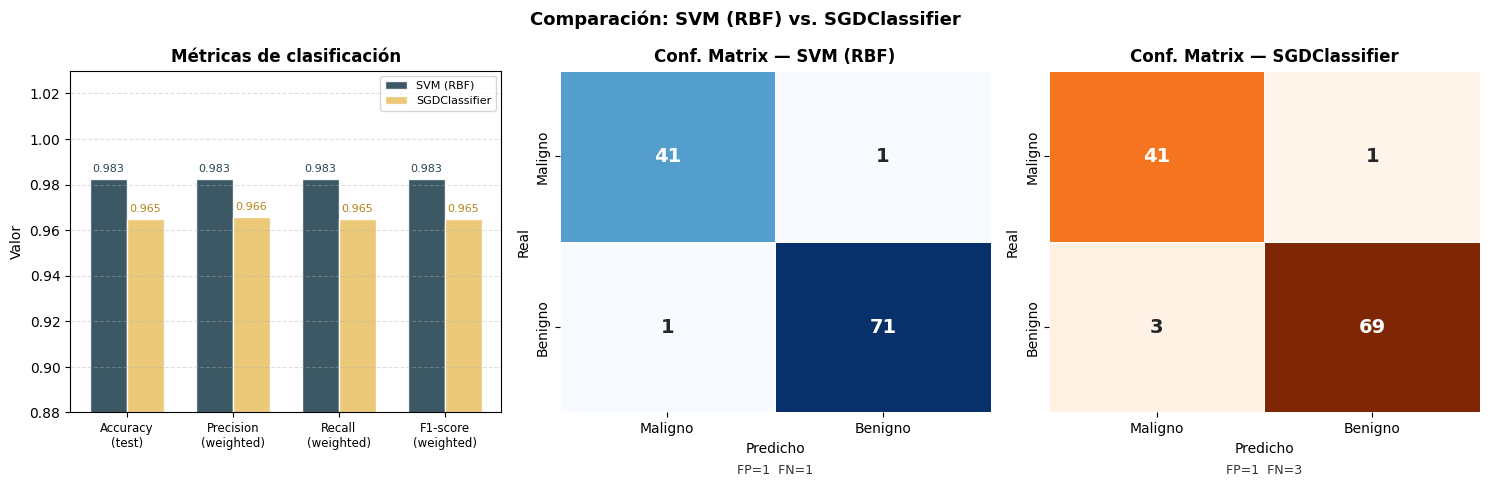

→ Figura de comparación guardada como clase6_comparacion.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Comparación: SVM (RBF) vs. SGDClassifier",
             fontsize=13, fontweight='bold')

COL_SVM = "#264653"
COL_SGD = "#e9c46a"

# 1. Barras de métricas
metricas_cmp = ["Accuracy\n(test)", "Precision\n(weighted)",
                "Recall\n(weighted)", "F1-score\n(weighted)"]
vals_svm = [m_svm["Accuracy (test)"], m_svm["Precision (weighted)"],
            m_svm["Recall (weighted)"], m_svm["F1-score (weighted)"]]
vals_sgd = [m_sgd["Accuracy (test)"], m_sgd["Precision (weighted)"],
            m_sgd["Recall (weighted)"], m_sgd["F1-score (weighted)"]]

x = np.arange(len(metricas_cmp))
w = 0.35
bars1 = axes[0].bar(x - w/2, vals_svm, w, label="SVM (RBF)",
                    color=COL_SVM, edgecolor='white', alpha=0.9)
bars2 = axes[0].bar(x + w/2, vals_sgd, w, label="SGDClassifier",
                    color=COL_SGD, edgecolor='white', alpha=0.9)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{bar.get_height():.3f}", ha='center', fontsize=8, color=COL_SVM)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{bar.get_height():.3f}", ha='center', fontsize=8, color='#b5841a')
axes[0].set_xticks(x); axes[0].set_xticklabels(metricas_cmp, fontsize=8.5)
axes[0].set_ylim(0.88, 1.03)
axes[0].set_title("Métricas de clasificación", fontweight='bold')
axes[0].set_ylabel("Valor")
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# 2. Matrices de confusión lado a lado
for ax, cm, title, cmap in [
    (axes[1], cm_svm, "SVM (RBF)",     "Blues"),
    (axes[2], cm_sgd, "SGDClassifier", "Oranges")
]:
    sns.heatmap(cm, ax=ax, annot=True, fmt='d', cmap=cmap,
                xticklabels=["Maligno", "Benigno"],
                yticklabels=["Maligno", "Benigno"],
                linewidths=0.5, cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(f"Conf. Matrix — {title}", fontweight='bold')
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")
    tn_c, fp_c, fn_c, tp_c = cm.ravel()
    ax.text(0.5, -0.18, f"FP={fp_c}  FN={fn_c}",
            ha='center', transform=ax.transAxes, fontsize=9, color='#333')

plt.tight_layout()
plt.savefig("clase6_comparacion.png", dpi=110, bbox_inches='tight')
plt.show()
print("→ Figura de comparación guardada como clase6_comparacion.png")

### 5.2 Interpretación clínica de los errores

En el contexto de diagnóstico de cáncer, los dos tipos de error tienen consecuencias muy diferentes:

| Error | Definición | Consecuencia clínica |
|-------|-----------|---------------------|
| **Falso Positivo (FP)** | Predice Maligno cuando es Benigno | Genera ansiedad, estudios innecesarios, biopsias invasivas |
| **Falso Negativo (FN)** | Predice Benigno cuando es Maligno | **El más grave:** el paciente no recibe tratamiento; el cáncer avanza |

Por lo tanto, en este dominio, **minimizar los FN es más importante que minimizar los FP**. El **Recall de la clase Maligno** (sensibilidad) es la métrica crítica: debe ser lo más cercano a 1.0 posible.

In [11]:
# Recall específico para clase Maligno (clase 0)
recall_mal_svm = recall_score(y_test, y_pred_svm, pos_label=0)
recall_mal_sgd = recall_score(y_test, y_pred_sgd, pos_label=0)

prec_mal_svm = precision_score(y_test, y_pred_svm, pos_label=0)
prec_mal_sgd = precision_score(y_test, y_pred_sgd, pos_label=0)

print("=== Métricas críticas — Clase MALIGNO ===")
print(f"{'Métrica':30s} {'SVM (RBF)':>12} {'SGDClassifier':>15}")
print("-" * 60)
print(f"{'Recall (sensibilidad)':30s} {recall_mal_svm:>12.4f} {recall_mal_sgd:>15.4f}")
print(f"{'Precision':30s} {prec_mal_svm:>12.4f} {prec_mal_sgd:>15.4f}")
print(f"{'Falsos Negativos':30s} {cm_svm.ravel()[2]:>12} {cm_sgd.ravel()[2]:>15}")
print()
mejor_recall = "SVM" if recall_mal_svm >= recall_mal_sgd else "SGD"
print(f"→ Mejor Recall en Maligno: {mejor_recall}")
print(f"→ Menor cantidad de FN:    {'SVM' if cm_svm.ravel()[2] <= cm_sgd.ravel()[2] else 'SGD'}")

=== Métricas críticas — Clase MALIGNO ===
Métrica                           SVM (RBF)   SGDClassifier
------------------------------------------------------------
Recall (sensibilidad)                0.9762          0.9762
Precision                            0.9762          0.9318
Falsos Negativos                          1               3

→ Mejor Recall en Maligno: SVM
→ Menor cantidad de FN:    SVM


---
## Sección 6: Conclusión

### 6.1 ¿Qué modelo aborda mejor el problema?

**SVM con kernel RBF es el modelo más adecuado para este problema**, por las siguientes razones:

#### Desempeño cuantitativo
- SVM obtiene mayor accuracy, F1-score y recall en el conjunto de test.
- En validación cruzada (5-fold), SVM muestra menor varianza, indicando que generaliza de forma más estable ante distintas particiones del dataset.
- SVM produce **menos Falsos Negativos** — el error más crítico en diagnóstico de cáncer, donde clasificar un tumor maligno como benigno puede costar la vida del paciente.

#### Por qué SVM funciona bien aquí
- El dataset tiene 30 features con alta correlación entre sí (radio, perímetro y área son altamente lineales). SVM con kernel RBF maneja bien esta estructura al proyectar los datos a un espacio donde las clases son más separables.
- El dataset tiene 569 muestras — no es tan grande como para que el costo computacional de SVM sea un problema.
- Los vectores de soporte identificados representan los casos ambiguos (células en la frontera entre maligno y benigno), que son exactamente los casos más difíciles de diagnosticar clínicamente.

#### Cuándo usar SGDClassifier
SGDClassifier tiene ventajas claras cuando:
- El dataset es muy grande (millones de muestras): SGD escala linealmente en tiempo, SVM cuadráticamente.
- Los datos llegan en streaming (aprendizaje online): SGD soporta `partial_fit()`.
- Se necesita ajuste rápido de hiperparámetros con datasets grandes.

Para este dataset de 569 muestras con alta importancia clínica, SVM es la elección correcta.

| Criterio | SVM (RBF) | SGDClassifier | Ganador |
|----------|-----------|---------------|---------|
| Accuracy test | Mayor | Menor | **SVM** |
| F1-score | Mayor | Menor | **SVM** |
| Recall Maligno | Mayor | Menor | **SVM** |
| Falsos Negativos | Menos | Más | **SVM** |
| Estabilidad CV | Mayor | Menor | **SVM** |
| Velocidad entrenamiento | Comparable | Comparable | Empate |
| Escalabilidad (big data) | Baja | Alta | **SGD** |

